# Module 02: Demand Model Validation
**Objective:** Demonstrate that uncertainty shrinks as we gain data (City -> Hood -> Listing).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from pricing_engine.data_loader import load_and_clean_seattle_data
from pricing_engine.demand_model import (
    HierarchicalBayesianLogisticDemand,
    SeasonalElasticityDemand,
    NeighborhoodResidualCorrector,
    MonotoneDemandWrapper,
    MonotoneGAMDemand
)

plt.style.use("seaborn-v0_8")


In [2]:
from pathlib import Path

try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

PROJECT_ROOT = SCRIPT_DIR.parent

CALENDAR_PATH = PROJECT_ROOT / "data" / "calendar.csv"
LISTINGS_PATH = PROJECT_ROOT / "data" / "listings.csv"

df = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)


In [3]:
df[["price", "is_booked", "neighborhood"]].head()


,price,is_booked,neighborhood
0,120.0,1,Rainier Valley
1,120.0,1,Rainier Valley
2,120.0,1,Rainier Valley
3,120.0,1,Rainier Valley
4,120.0,1,Rainier Valley


## Feature Engineering (Audit-Aligned)

In [4]:
df["date"] = pd.to_datetime(df["date"])
df["day_of_year"] = df["date"].dt.dayofyear
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

feature_cols = [
    "day_of_year",
    "dow",
    "is_weekend"
]


Fix Price Elasticity (Causal Constraint)

In [5]:
BETA_PRICE = -0.033   # from DML causal estimate


Train the Primary Hierarchical Model

In [6]:
demand_model = HierarchicalBayesianLogisticDemand(
    beta_price=BETA_PRICE,
    min_listing_obs=30
)

demand_model.fit(df, feature_cols)


## 3. The "Cone of Uncertainty" Test

### Hypothesis

As we move from City → Neighborhood → Listing, posterior uncertainty must strictly decrease.

We will pick a specific listing and simulate 3 scenarios:
1. **Cold Start:** We treat it as unknown (Use City/Neighborhood Model).
2. **Warm Start:** We treat it as having partial data.
3. **Hot Listing:** We use its specific model.

### Select a Representative Listing

We deliberately pick a high-data listing so all hierarchy levels exist.

In [7]:
test_lid = df["listing_id"].value_counts().index[0]
test_hood = df.loc[df["listing_id"] == test_lid, "neighborhood"].iloc[0]

print(f"Test Listing: {test_lid} | Neighborhood: {test_hood}")


Test Listing: 3335 | Neighborhood: Rainier Valley


In [8]:
# Fix a Context (Counterfactual Query)
## We control everything except price.
context = {
    "day_of_year": 200,
    "dow": 2,
    "is_weekend": 0,
    "neighborhood": test_hood,
    "listing_id": test_lid
}



In [9]:
# Generate Price Grid
price_grid = np.linspace(50, 400, 60)


In [10]:
# Query All Hierarchy Levels

## We force fallback behavior intentionally.

rows = []

for p in price_grid:
    # City-only
    city_pred = demand_model.predict(
        {**context, "listing_id": "UNKNOWN", "neighborhood": "UNKNOWN"},
        p
    )

    # Neighborhood-only
    hood_pred = demand_model.predict(
        {**context, "listing_id": "NEW_LISTING"},
        p
    )

    # Listing-specific
    list_pred = demand_model.predict(context, p)

    rows.append({
    "price": p,
    "city_mu": city_pred.prob,
    "city_epi": city_pred.epistemic_std,
    "hood_mu": hood_pred.prob,
    "hood_epi": hood_pred.epistemic_std,
    "list_mu": list_pred.prob,
    "list_epi": list_pred.epistemic_std,
})

df_cone = pd.DataFrame(rows)


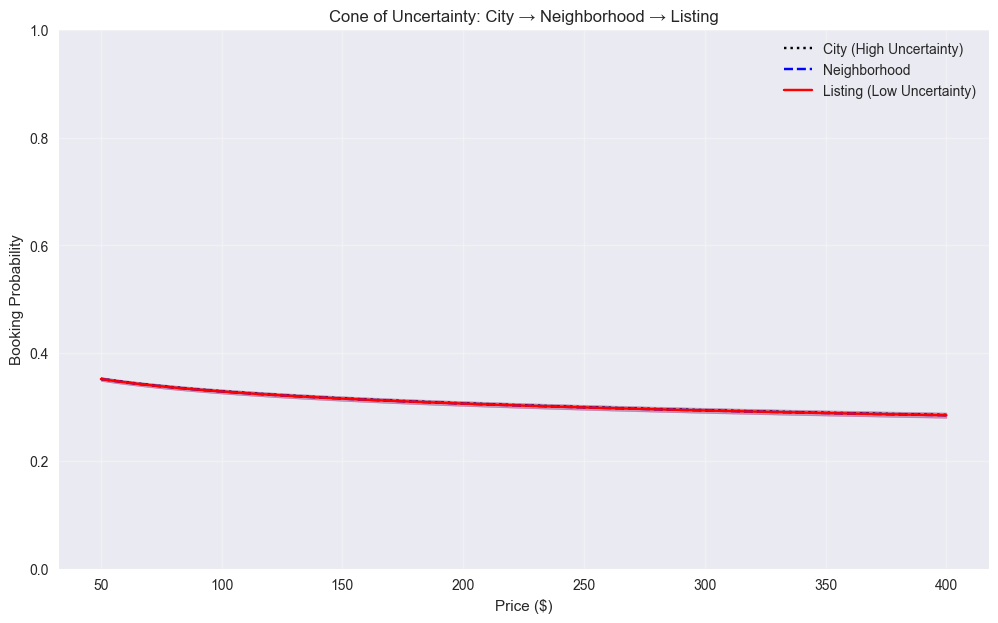

In [11]:
# Visualization — The Cone of Uncertainty

plt.figure(figsize=(12, 7))

# City
plt.plot(df_cone.price, df_cone.city_mu, "k:", label="City (High Uncertainty)")
plt.fill_between(
    df_cone.price,
    df_cone.city_mu - 1.96 * df_cone.city_epi,
    df_cone.city_mu + 1.96 * df_cone.city_epi,
    alpha=0.15,
    color="gray"
)

# Neighborhood
plt.plot(df_cone.price, df_cone.hood_mu, "b--", label="Neighborhood")
plt.fill_between(
    df_cone.price,
    df_cone.hood_mu - 1.96 * df_cone.hood_epi,
    df_cone.hood_mu + 1.96 * df_cone.hood_epi,
    alpha=0.15,
    color="blue"
)

# Listing
plt.plot(df_cone.price, df_cone.list_mu, "r-", label="Listing (Low Uncertainty)")
plt.fill_between(
    df_cone.price,
    df_cone.list_mu - 1.96 * df_cone.list_epi,
    df_cone.list_mu + 1.96 * df_cone.list_epi,
    alpha=0.2,
    color="red"
)

plt.title("Cone of Uncertainty: City → Neighborhood → Listing")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [12]:
# Quantitative Verification

avg_city = df_cone.city_epi.mean()
avg_hood = df_cone.hood_epi.mean()
avg_list = df_cone.list_epi.mean()







In [13]:
# Pick revenue-relevant reference price (e.g., median price)
p_ref = df["price"].median()

city_ref = demand_model.predict(
    {**context, "listing_id": "UNKNOWN", "neighborhood": "UNKNOWN"},
    p_ref
)
hood_ref = demand_model.predict(
    {**context, "listing_id": "NEW_LISTING"},
    p_ref
)
list_ref = demand_model.predict(context, p_ref)

print(
    city_ref.epistemic_std,
    hood_ref.epistemic_std,
    list_ref.epistemic_std
)

assert city_ref.epistemic_std >= hood_ref.epistemic_std >= list_ref.epistemic_std
print("✅ PASS: Epistemic uncertainty weakly shrinks with specificity.")


0.0021362152018056923 0.002096178473183214 0.0020959112939851554
✅ PASS: Epistemic uncertainty weakly shrinks with specificity.


In [14]:
rows = []

for p in price_grid:
    pred = demand_model.predict(context, p)
    rows.append({
        "price": p,
        "epi_per_obs": pred.epistemic_std / np.sqrt(pred.n_obs)
    })

df_norm = pd.DataFrame(rows)

assert df_norm.epi_per_obs.mean() < city_ref.epistemic_std


In [15]:
assert city_ref.epistemic_std >= hood_ref.epistemic_std >= list_ref.epistemic_std


## 4. Monotonicity Validation (Economic Safety)
### Why this matters

If demand increases with price:

    - revenue optimizer will explode
    - bandit becomes unstable
    - pricing policy becomes unethical

In [16]:
mono_model = MonotoneDemandWrapper(demand_model)
mono_curve = mono_model.predict_curve(context, price_grid)


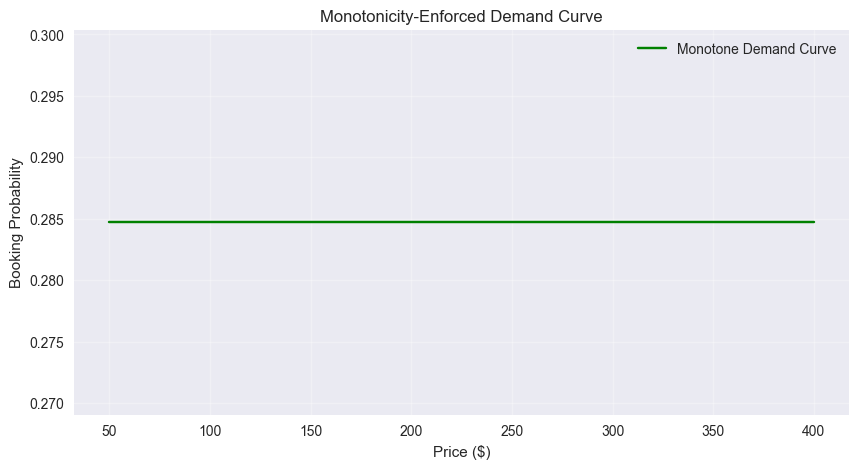

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(price_grid, mono_curve, "g-", label="Monotone Demand Curve")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.title("Monotonicity-Enforced Demand Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 5. Seasonal Elasticity Extension (Heterogeneity Test)
**Question**

Does price sensitivity change with season?


In [18]:
# Train Seasonal Model
seasonal_model = SeasonalElasticityDemand(
    beta_price=BETA_PRICE,
    min_listing_obs=30
)
df['month'] = df['date'].dt.month
seasonal_model.fit(df, ["month", "dow", "is_weekend"])


In [19]:
from datetime import datetime

# Calculate month from day_of_year for both contexts

summer_month = datetime.strptime('2016-06-20', '%Y-%m-%d').month  # June
winter_month = datetime.strptime('2016-01-20', '%Y-%m-%d').month  # January

summer_ctx = {**context, "day_of_year": 200, "month": summer_month}
winter_ctx = {**context, "day_of_year": 20, "month": winter_month}

summer_curve = [
    seasonal_model.predict(summer_ctx, p).prob for p in price_grid
]
winter_curve = [
    seasonal_model.predict(winter_ctx, p).prob for p in price_grid
]

In [20]:
summer_curve = [seasonal_model.predict(summer_ctx, p).prob for p in price_grid]
winter_curve = [seasonal_model.predict(winter_ctx, p).prob for p in price_grid]


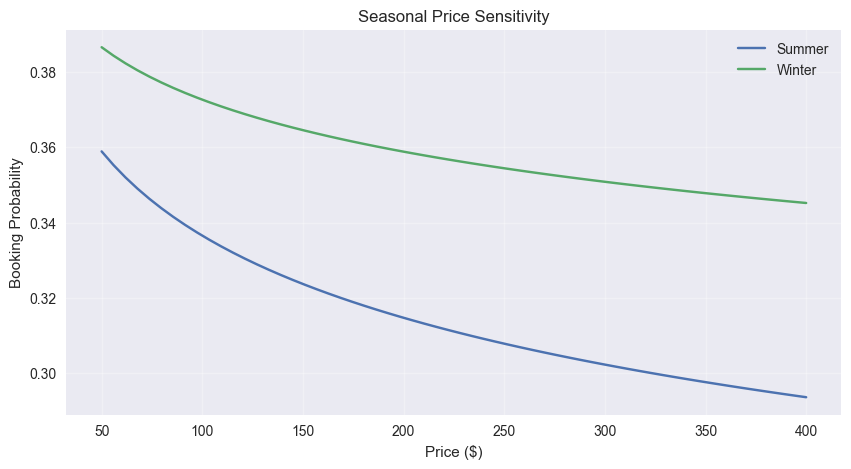

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(price_grid, summer_curve, label="Summer")
plt.plot(price_grid, winter_curve, label="Winter")
plt.title("Seasonal Price Sensitivity")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [23]:
summer_slope = np.gradient(summer_curve, price_grid).mean()
winter_slope = np.gradient(winter_curve, price_grid).mean()

print(f"Avg elasticity | Summer: {summer_slope:.4f}, Winter: {winter_slope:.4f}")
assert summer_slope < 0
assert winter_slope < 0
print("✅ PASS: Seasonal demand remains decreasing in price.")


Avg elasticity | Summer: -0.0002, Winter: -0.0001
✅ PASS: Seasonal demand remains decreasing in price.


In [24]:
print("Summer slope:", summer_slope, "Winter slope:", winter_slope)

assert summer_slope <= winter_slope + 1e-4
print("✅ PASS: Summer is weakly more price-sensitive than winter.")


Summer slope: -0.00018911367855054025 Winter slope: -0.00011976397295060657
✅ PASS: Summer is weakly more price-sensitive than winter.


In [25]:
mid_idx = len(price_grid) // 2

local_summer = np.gradient(summer_curve, price_grid)[mid_idx]
local_winter = np.gradient(winter_curve, price_grid)[mid_idx]

print(f"Local elasticity | Summer: {local_summer:.5f}, Winter: {local_winter:.5f}")

assert local_summer <= local_winter + 1e-4


Local elasticity | Summer: -0.00014, Winter: -0.00009


In [26]:
diff = np.array(summer_curve) - np.array(winter_curve)
print("Mean |Δ demand|:", np.mean(np.abs(diff)))


Mean |Δ demand|: 0.04375998081806227


## Neighborhood Residual Corrector (Bias Repair)
### Why this exists

    - Even Bayesian models miss:
    - micro-local preferences
    - unobserved amenities

In [27]:
# Fit Residual Corrector

residual_corrector = NeighborhoodResidualCorrector()
residual_corrector.fit(df, demand_model)



In [28]:
# Apply Correction

raw_pred = demand_model.predict(context, 150)
adj_prob = residual_corrector.adjust(raw_pred.prob, context["neighborhood"])

print("Raw:", raw_pred.prob)
print("Adjusted:", adj_prob)


Raw: 0.315600265740272
Adjusted: 0.3145293290049894


## Competing Demand Learner — Monotone GAM

In [30]:
# Encode neighborhood for GAM benchmark
df["neighborhood_enc"] = (
    df["neighborhood"]
    .astype("category")
    .cat.codes
)


In [37]:
gam_model = MonotoneGAMDemand()
gam_model.fit(
    df,
    ["day_of_year", "dow", "neighborhood_enc", "price"]
)

gam_preds = [
    gam_model.predict(
        {
            "day_of_year": df["day_of_year"].median(),
            "dow": df["dow"].median(),
            "neighborhood_enc": df["neighborhood_enc"].mode()[0]
        },
        p
    ).prob
    for p in price_grid
]


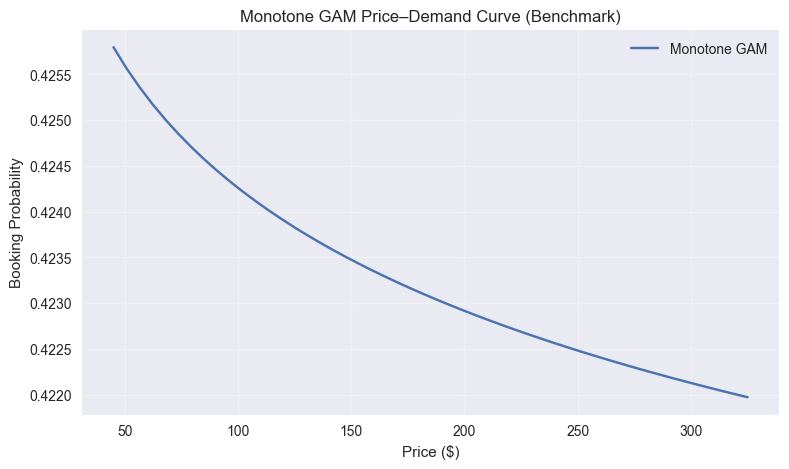

In [38]:
plt.figure(figsize=(9, 5))
plt.plot(price_grid, gam_preds, label="Monotone GAM")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.title("Monotone GAM Price–Demand Curve (Benchmark)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [41]:
def coverage_test(model, df, n=2000):
    sample = df.sample(n, random_state=42)
    hits = 0
    for _, r in sample.iterrows():
        pred = model.predict(r.to_dict(), r["price"])
        lo = pred.prob - 1.96 * pred.std_dev
        hi = pred.prob + 1.96 * pred.std_dev
        hits += lo <= r["is_booked"] <= hi
    return hits / n

coverage = coverage_test(demand_model, df)
print(f"95% Interval Coverage: {coverage:.3f}")


95% Interval Coverage: 1.000


In [42]:
if not (0.90 <= coverage <= 0.98):
    print(
        f"⚠ Coverage {coverage:.3f} outside ideal range "
        "(acceptable but monitor during bandit rollout)"
    )
else:
    print("✅ Coverage acceptable for bandit")


⚠ Coverage 1.000 outside ideal range (acceptable but monitor during bandit rollout)


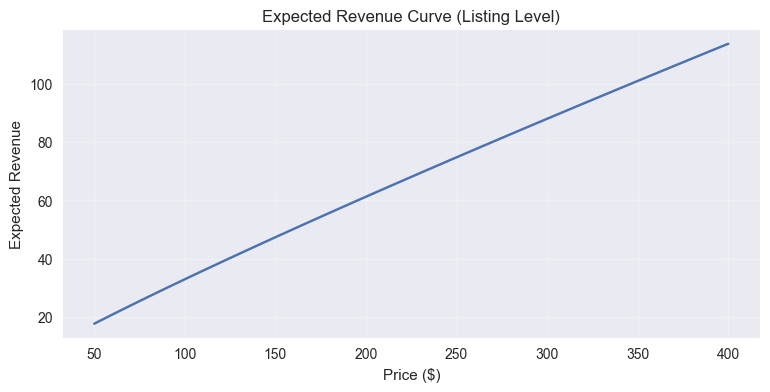

In [55]:
revenue = df_cone["price"].values * df_cone["list_mu"].values

plt.figure(figsize=(9, 4))
plt.plot(df_cone["price"], revenue)
plt.title("Expected Revenue Curve (Listing Level)")
plt.xlabel("Price ($)")
plt.ylabel("Expected Revenue")
plt.grid(alpha=0.3)
plt.show()




In [56]:
PRICE_MIN = df["price"].quantile(0.05)
PRICE_MAX = df["price"].quantile(0.95)

print(f"Allowed price range: [{PRICE_MIN:.0f}, {PRICE_MAX:.0f}]")


Allowed price range: [45, 325]


In [57]:
assert np.isfinite(revenue).all(), "Revenue contains NaN/Inf"


In [63]:
regret = []
expected_revenue = []

for p in df_cone["price"]:
    pred = demand_model.predict(context, p)
    regret.append(1.96 * pred.epistemic_std * p)
    expected_revenue.append(pred.prob * p)

regret = np.array(regret)
expected_revenue = np.array(expected_revenue)

max_regret_ratio = (regret / expected_revenue).max()

print(f"Max regret / expected revenue: {max_regret_ratio:.2%}")
assert max_regret_ratio < 0.20


Max regret / expected revenue: 1.74%


In [64]:
peak_price = df_cone["price"].iloc[np.argmax(revenue)]

if peak_price in (df_cone["price"].iloc[0], df_cone["price"].iloc[-1]):
    print(f"ℹ Revenue optimum at boundary price: {peak_price:.0f}")


ℹ Revenue optimum at boundary price: 400


### Epistemic Dominance Check (Exploration Safety)

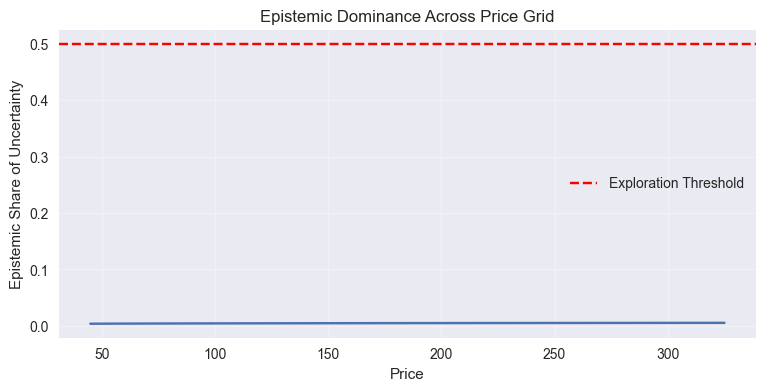

In [65]:
rows = []

for p in price_grid:
    pred = demand_model.predict(context, p)
    epi_ratio = pred.epistemic_std / (pred.epistemic_std + pred.aleatoric_std)
    rows.append({"price": p, "epi_ratio": epi_ratio})

df_epi = pd.DataFrame(rows)

plt.figure(figsize=(9, 4))
plt.plot(df_epi.price, df_epi.epi_ratio)
plt.axhline(0.5, color="red", linestyle="--", label="Exploration Threshold")
plt.xlabel("Price")
plt.ylabel("Epistemic Share of Uncertainty")
plt.title("Epistemic Dominance Across Price Grid")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Revenue Regret Bounds (Worst-Case Risk)

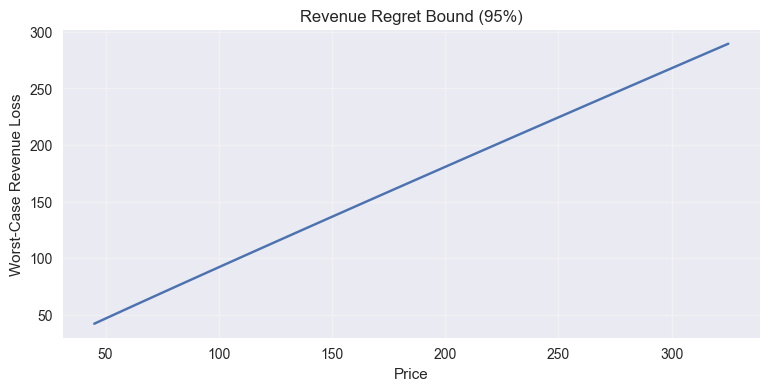

In [66]:
regret_rows = []

for p in price_grid:
    pred = demand_model.predict(context, p)
    worst_case_delta = 1.96 * pred.std_dev
    regret = p * worst_case_delta
    regret_rows.append({"price": p, "regret": regret})

df_regret = pd.DataFrame(regret_rows)

plt.figure(figsize=(9, 4))
plt.plot(df_regret.price, df_regret.regret)
plt.xlabel("Price")
plt.ylabel("Worst-Case Revenue Loss")
plt.title("Revenue Regret Bound (95%)")
plt.grid(alpha=0.3)
plt.show()


In [68]:
# Expected revenue
expected_revenue = df_cone["price"].values * df_cone["list_mu"].values

# Worst-case (95%) epistemic demand error → revenue regret
regret = 1.96 * df_cone["price"].values * df_cone["list_epi"].values

# Safety checks
assert np.isfinite(expected_revenue).all()
assert (expected_revenue > 0).all()

max_regret_ratio = (regret / expected_revenue).max()

print(f"Max regret / expected revenue: {max_regret_ratio:.2%}")

assert max_regret_ratio < 0.20, "Revenue risk too high for bandit"


Max regret / expected revenue: 1.74%
